In [64]:
import pandas as pd

df = pd.read_csv("../data/processed/obis/obis_clean.csv")

df.head()

,scientificName,species,genus,family,decimalLatitude,decimalLongitude,eventDate,depth,sst,sss,individualCount
0,Thunnus albacares,Thunnus albacares,Thunnus,Scombridae,-31.038799,30.232300,2000-07-12T12:00:00Z,NaN,23.58,35.31,NaN
1,Thunnus albacares,Thunnus albacares,Thunnus,Scombridae,27.330000,-89.280000,1995-02-15,162.0,26.11,35.82,3.0
2,Thunnus obesus,Thunnus obesus,Thunnus,Scombridae,18.333473,-20.166805,NaN,NaN,23.26,36.14,NaN
3,Thunnus obesus,Thunnus obesus,Thunnus,Scombridae,0.883472,0.416806,NaN,NaN,27.62,34.70,NaN
4,Thunnus alalunga,Thunnus alalunga,Thunnus,Scombridae,-34.356899,18.497200,1998-12-29T12:00:00Z,NaN,17.19,35.43,NaN


In [65]:
df[["decimalLatitude", "decimalLongitude"]].head()

,decimalLatitude,decimalLongitude
0,-31.038799,30.232300
1,27.330000,-89.280000
2,18.333473,-20.166805
3,0.883472,0.416806
4,-34.356899,18.497200


In [66]:
map_df = df.dropna(
    subset=["decimalLatitude", "decimalLongitude"]
).copy()

print(f"Records available for mapping: {len(map_df)}")

Records available for mapping: 100


In [67]:
import folium

m = folium.Map(
    location=[20, 0],
    zoom_start=2
)

for _, row in map_df.iterrows():

    folium.CircleMarker(
        location=[
            row["decimalLatitude"],
            row["decimalLongitude"]
        ],
        radius=5,
        popup=row.get("scientificName", "Unknown species"),
        fill=True
    ).add_to(m)

m

In [68]:
m.save("../data/processed/obis/obis_species_map.html")

print("Map saved!")

Map saved!


In [69]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster

df = pd.read_csv("../data/processed/obis/obis_clean.csv")

map_df = df.dropna(
    subset=["decimalLatitude", "decimalLongitude"]
).copy()

print(f"Records available: {len(map_df)}")

Records available: 100


In [70]:
m = folium.Map(
    location=[20, 0],
    zoom_start=2
)

marker_cluster = MarkerCluster().add_to(m)

for _, row in map_df.iterrows():

    species = row.get("scientificName", "Unknown")
    latitude = row["decimalLatitude"]
    longitude = row["decimalLongitude"]

    depth = row.get("depth", "N/A")
    sst = row.get("sst", "N/A")
    sss = row.get("sss", "N/A")
    date = row.get("eventDate", "N/A")

    popup = f"""
    <b>Species:</b> {species}<br>
    <b>Latitude:</b> {latitude}<br>
    <b>Longitude:</b> {longitude}<br>
    <b>Depth:</b> {depth}<br>
    <b>Sea Surface Temperature:</b> {sst}<br>
    <b>Sea Surface Salinity:</b> {sss}<br>
    <b>Date:</b> {date}
    """

    folium.CircleMarker(
        location=[latitude, longitude],
        radius=5,
        popup=folium.Popup(popup, max_width=350),
        fill=True
    ).add_to(marker_cluster)

m

In [71]:
map_df["scientificName"].value_counts()

scientificName
Thunnus albacares     52
Thunnus alalunga      22
Thunnus obesus        21
Thunnus orientalis     2
Thunnus atlanticus     2
Thunnus maccoyii       1
Name: count, dtype: int64

In [72]:
from ipywidgets import interact, Dropdown

species_list = sorted(
    map_df["scientificName"].dropna().unique()
)

species_dropdown = Dropdown(
    options=["All"] + species_list,
    description="Species:"
)

display(species_dropdown)

Dropdown(description='Species:', options=('All', 'Thunnus alalunga', 'Thunnus albacares', 'Thunnus atlanticus'…

In [73]:
def create_species_map(selected_species):

    if selected_species == "All":
        filtered_df = map_df
    else:
        filtered_df = map_df[
            map_df["scientificName"] == selected_species
        ]

    new_map = folium.Map(
        location=[20, 0],
        zoom_start=2
    )

    marker_cluster = MarkerCluster().add_to(new_map)

    for _, row in filtered_df.iterrows():

        species = row.get("scientificName", "Unknown")
        latitude = row["decimalLatitude"]
        longitude = row["decimalLongitude"]
        depth = row.get("depth", "N/A")
        sst = row.get("sst", "N/A")
        sss = row.get("sss", "N/A")
        date = row.get("eventDate", "N/A")

        popup = f"""
        <b>Species:</b> {species}<br>
        <b>Latitude:</b> {latitude}<br>
        <b>Longitude:</b> {longitude}<br>
        <b>Depth:</b> {depth}<br>
        <b>Sea Surface Temperature:</b> {sst}<br>
        <b>Sea Surface Salinity:</b> {sss}<br>
        <b>Date:</b> {date}
        """

        folium.CircleMarker(
            location=[latitude, longitude],
            radius=5,
            popup=folium.Popup(popup, max_width=350),
            fill=True
        ).add_to(marker_cluster)

    return new_map

In [74]:
from ipywidgets import interact

interact(
    create_species_map,
    selected_species=species_dropdown
)

interactive(children=(Dropdown(description='Species:', options=('All', 'Thunnus alalunga', 'Thunnus albacares'…

<function __main__.create_species_map(selected_species)>

In [75]:
df[[
    "scientificName",
    "depth",
    "sst",
    "sss"
]].head(10)

,scientificName,depth,sst,sss
0,Thunnus albacares,NaN,23.58,35.31
1,Thunnus albacares,162.0,26.11,35.82
2,Thunnus obesus,NaN,23.26,36.14
3,Thunnus obesus,NaN,27.62,34.70
4,Thunnus alalunga,NaN,17.19,35.43
5,Thunnus obesus,NaN,23.40,35.48
6,Thunnus alalunga,NaN,17.19,35.43
7,Thunnus albacares,NaN,28.47,35.79
8,Thunnus albacares,140.0,26.31,36.21
9,Thunnus alalunga,45.0,26.37,36.63


In [76]:
environment_summary = df[
    ["depth", "sst", "sss"]
].describe()

environment_summary

,depth,sst,sss
count,52.000000,93.000000,93.000000
mean,293.230769,23.843441,35.549247
std,587.666326,4.401129,0.669651
min,0.000000,13.110000,33.540000
25%,21.500000,19.550000,35.080000
50%,45.000000,25.900000,35.580000
75%,153.000000,27.070000,36.120000
max,2425.000000,29.060000,36.690000


In [77]:
species_temperature = (
    df.groupby("scientificName")["sst"]
    .mean()
    .sort_values()
)

species_temperature

scientificName
Thunnus alalunga      19.204706
Thunnus maccoyii      19.360000
Thunnus obesus        24.388095
Thunnus orientalis    24.420000
Thunnus albacares     25.179000
Thunnus atlanticus    25.830000
Name: sst, dtype: float64

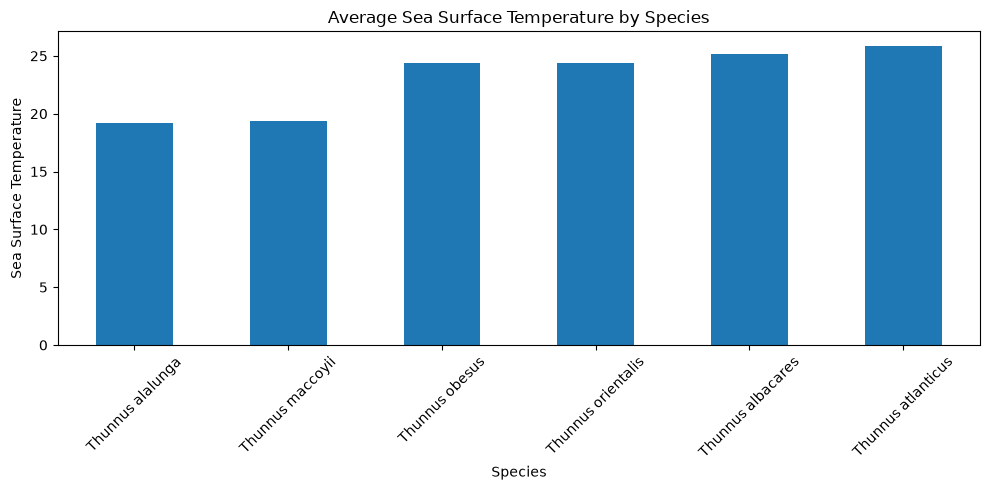

In [78]:
import matplotlib.pyplot as plt

species_temperature.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Sea Surface Temperature by Species")
plt.xlabel("Species")
plt.ylabel("Sea Surface Temperature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
species_depth = (
    df.groupby("scientificName")["depth"]
    .mean()
    .sort_values()
)

species_depth

scientificName
Thunnus maccoyii        0.000000
Thunnus albacares     128.903226
Thunnus atlanticus    135.000000
Thunnus alalunga      403.428571
Thunnus obesus        741.636364
Thunnus orientalis           NaN
Name: depth, dtype: float64

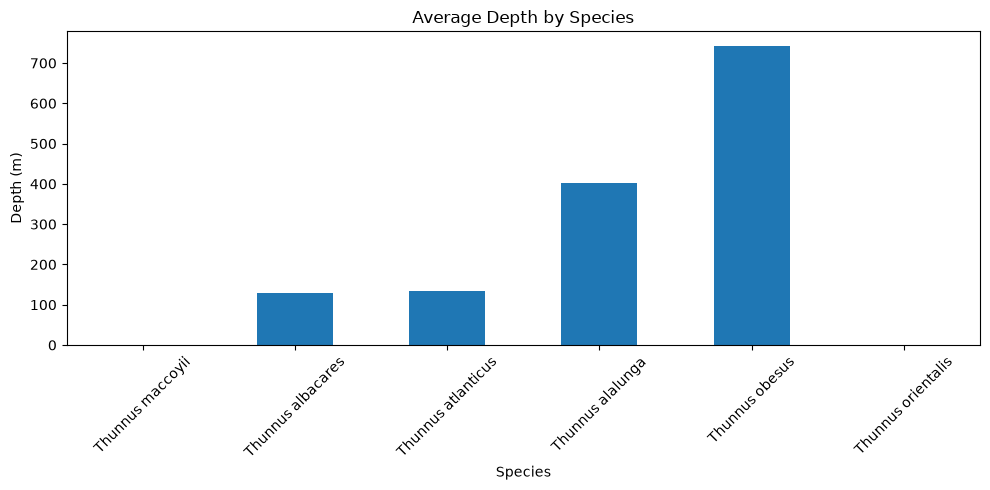

In [80]:
species_depth.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Depth by Species")
plt.xlabel("Species")
plt.ylabel("Depth (m)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [81]:

import pandas as pd
import folium
from folium.plugins import MarkerCluster

df = pd.read_csv("../data/processed/obis/obis_clean.csv")

map_df = df.dropna(
    subset=["decimalLatitude", "decimalLongitude"]
).copy()

m = folium.Map(
    location=[20, 0],
    zoom_start=2
)

marker_cluster = MarkerCluster().add_to(m)

for _, row in map_df.iterrows():

    species = row.get("scientificName", "Unknown")
    latitude = row["decimalLatitude"]
    longitude = row["decimalLongitude"]
    depth = row.get("depth", "N/A")
    sst = row.get("sst", "N/A")
    sss = row.get("sss", "N/A")
    date = row.get("eventDate", "N/A")

    popup = f"""
    <b>Species:</b> {species}<br>
    <b>Latitude:</b> {latitude}<br>
    <b>Longitude:</b> {longitude}<br>
    <b>Depth:</b> {depth}<br>
    <b>Sea Surface Temperature:</b> {sst}<br>
    <b>Sea Surface Salinity:</b> {sss}<br>
    <b>Date:</b> {date}
    """

    folium.CircleMarker(
        location=[latitude, longitude],
        radius=5,
        popup=folium.Popup(popup, max_width=350),
        fill=True
    ).add_to(marker_cluster)

m

In [82]:
m.save("../data/processed/obis/updated_species_map.html")

print("Updated map saved!")

Updated map saved!


In [83]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
from branca.element import Template, MacroElement

# Load data
df = pd.read_csv("../data/processed/obis/obis_clean.csv")

# Keep records with coordinates
map_df = df.dropna(
    subset=["decimalLatitude", "decimalLongitude"]
).copy()

# Create map
m = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="OpenStreetMap"
)

# Create one layer for each species
species_list = sorted(
    map_df["scientificName"].dropna().unique()
)

species_layers = {}

for species in species_list:

    species_data = map_df[
        map_df["scientificName"] == species
    ]

    layer = folium.FeatureGroup(
        name=species,
        show=True
    )

    for _, row in species_data.iterrows():

        depth = row.get("depth", "N/A")
        sst = row.get("sst", "N/A")
        sss = row.get("sss", "N/A")
        date = row.get("eventDate", "N/A")

        popup = f"""
        <div style="width:300px">

        <h4>🌊 Marine Observation</h4>

        <b>Species:</b><br>
        {species}

        <br><br>

        <b>📍 Location</b><br>
        Latitude: {row["decimalLatitude"]}<br>
        Longitude: {row["decimalLongitude"]}

        <br><br>

        <b>🌊 Environmental Data</b><br>
        Depth: {depth}<br>
        Sea Surface Temperature: {sst}<br>
        Sea Surface Salinity: {sss}

        <br><br>

        <b>📅 Observation Date:</b><br>
        {date}

        </div>
        """

        folium.CircleMarker(
            location=[
                row["decimalLatitude"],
                row["decimalLongitude"]
            ],
            radius=5,
            popup=folium.Popup(
                popup,
                max_width=350
            ),
            tooltip=species,
            fill=True
        ).add_to(layer)

    layer.add_to(m)

# Add layer control
folium.LayerControl(
    collapsed=False
).add_to(m)

# Save
m.save(
    "../data/processed/obis/updated_species_map.html"
)

print("Updated map created successfully!")

Updated map created successfully!
